## Questão 3 – Regressão

**Enunciado:**  
Faça um código em Python para construir um problema de Regressão a partir da base escolhida, seja utilizando o alvo original quando ele for numérico, seja definindo uma variável quantitativa derivada coerente com o cenário. Implemente pelo menos dois modelos de regressão, compare desempenho com métricas adequadas e analise os resíduos, discutindo se há sinais de não linearidade, heterocedasticidade ou influência excessiva de outliers.

### Raciocínio

A Questão 1 confirmou que a Telco não tem alvo numérico natural — `Churn` é binário. A Questão 2 revelou, porém, que `MonthlyCharges` e `TotalCharges` têm **correlação de 0.65–0.83** entre si dentro de cada classe, e que `TotalCharges ≈ MonthlyCharges × tenure`. Isso sugere um subproblema de regressão coerente com o cenário de negócio: **prever o valor total gasto pelo cliente (`TotalCharges`) a partir do seu perfil de serviço e tempo de contrato**.

Por que isso tem valor de negócio? Estimar `TotalCharges` antes de completar o ciclo de contrato permite ao time comercial calcular o **LTV projetado** (*Lifetime Value*) de novos clientes — uma métrica diretamente ligada a decisões de investimento em retenção e aquisição. Clientes com LTV projetado alto e risco de churn elevado são os candidatos prioritários a campanhas de retenção.

**Dois modelos serão comparados:**
1. **Regressão Linear Múltipla** — linha de base interpretável, diretamente amparada pela aula 11, com coeficientes que permitem leitura de negócio
2. **Regressão com Interação `tenure × MonthlyCharges`** — estende o modelo linear incluindo o produto entre as duas variáveis mais correlacionadas com `TotalCharges`, capturando a relação que a Q2 identificou como estrutural (total = mensal × tempo)

A análise de resíduos verificará heterocedasticidade, não linearidade e outliers influentes — os três critérios exigidos pelo enunciado.

**Métricas:** MAE, RMSE e R². O R² mede quanto da variação em `TotalCharges` é explicada pelo modelo; MAE e RMSE medem o erro médio em reais, tornando o resultado interpretável no contexto de negócio.

### Desenvolvimento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

In [3]:
# ── Pré-processamento herdado das questões anteriores ────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

# Corrige tipagem e imputa TotalCharges (estratégia vencedora da Lista 1, Q3)
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
mask_missing = df['TotalCharges'].isna()
df.loc[mask_missing, 'TotalCharges'] = (
    df.loc[mask_missing, 'MonthlyCharges'] * df.loc[mask_missing, 'tenure']
)

# Remove identificador
df.drop(columns=['customerID'], inplace=True)

# Padroniza categorias de serviço
SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

print(f'Base pronta: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Ausentes restantes: {df.isna().sum().sum()}')

Base pronta: 7043 linhas × 20 colunas
Ausentes restantes: 0


In [4]:
# ── Definição do subproblema de regressão ─────────────────────────────────────
# Alvo: TotalCharges (valor total gasto pelo cliente)
# Features: tudo exceto TotalCharges e Churn (o alvo de classificação)

TARGET_REG = 'TotalCharges'
EXCLUDE    = ['TotalCharges', 'Churn']

X = df.drop(columns=EXCLUDE)
y = df[TARGET_REG]

NUM_COLS = ['tenure', 'MonthlyCharges']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

print(f'Alvo: {TARGET_REG}')
print(f'  Média: R$ {y.mean():.2f} | Mediana: R$ {y.median():.2f} | Desvio: R$ {y.std():.2f}')
print(f'  Mín: R$ {y.min():.2f} | Máx: R$ {y.max():.2f}')
print(f'\nFeatures numéricas ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Features categóricas ({len(CAT_COLS)}): {CAT_COLS}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'\nTreino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')

Alvo: TotalCharges
  Média: R$ 2279.73 | Mediana: R$ 1394.55 | Desvio: R$ 2266.79
  Mín: R$ 0.00 | Máx: R$ 8684.80

Features numéricas (2): ['tenure', 'MonthlyCharges']
Features categóricas (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Treino: 5634 | Teste: 1409


In [6]:
# ── Função de avaliação ───────────────────────────────────────────────────────
def evaluate_regression(pipeline, X_tr, y_tr, X_te, y_te, model_name):
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    residuals = y_te.values - y_pred

    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)

    return {
        'modelo'    : model_name,
        'MAE'       : round(mae, 2),
        'RMSE'      : round(rmse, 2),
        'R2'        : round(r2, 4),
        'y_pred'    : y_pred,
        'residuals' : residuals,
        'pipeline'  : pipeline
    }


def cv_regression(pipeline, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        pipeline, X, y, cv=kf,
        scoring=['r2', 'neg_mean_absolute_error'],
        return_train_score=False
    )
    return {
        'R2_cv_mean' : round(scores['test_r2'].mean(), 4),
        'R2_cv_std'  : round(scores['test_r2'].std(), 4),
        'MAE_cv_mean': round(-scores['test_neg_mean_absolute_error'].mean(), 2),
    }

In [7]:
# ── Modelo 1: Regressão Linear Múltipla (baseline) ────────────────────────────
# OHE nas categóricas + StandardScaler nas numéricas
# Modelo direto da aula 11: Y = β0 + β1·X1 + β2·X2 + ... + ε

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_linear = Pipeline([
    ('prep', preprocessor),
    ('reg' , LinearRegression())
])

res_linear = evaluate_regression(pipe_linear, X_train, y_train, X_test, y_test, 'Linear Múltipla')
cv_linear  = cv_regression(pipe_linear, X, y)

print('Modelo 1 — Regressão Linear Múltipla')
print(f'  MAE  : R$ {res_linear["MAE"]:.2f}')
print(f'  RMSE : R$ {res_linear["RMSE"]:.2f}')
print(f'  R²   : {res_linear["R2"]}')
print(f'  R² CV (5-fold): {cv_linear["R2_cv_mean"]} ± {cv_linear["R2_cv_std"]}')
print(f'  MAE CV (5-fold): R$ {cv_linear["MAE_cv_mean"]}')

Modelo 1 — Regressão Linear Múltipla
  MAE  : R$ 569.42
  RMSE : R$ 703.17
  R²   : 0.905
  R² CV (5-fold): 0.9067 ± 0.0023
  MAE CV (5-fold): R$ 558.51


In [8]:
# ── Modelo 2: Regressão com Interação tenure × MonthlyCharges ─────────────────
# A Q2 mostrou que TotalCharges ≈ MonthlyCharges × tenure estruturalmente.
# Adicionar esse produto como feature explicita essa relação ao modelo linear,
# que por si só não captura interações multiplicativas.

X_inter_train = X_train.copy()
X_inter_test  = X_test.copy()

X_inter_train['tenure_x_monthly'] = X_inter_train['tenure'] * X_inter_train['MonthlyCharges']
X_inter_test['tenure_x_monthly']  = X_inter_test['tenure']  * X_inter_test['MonthlyCharges']

NUM_COLS_INTER = NUM_COLS + ['tenure_x_monthly']

preprocessor_inter = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS_INTER),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_inter = Pipeline([
    ('prep', preprocessor_inter),
    ('reg' , LinearRegression())
])

res_inter = evaluate_regression(pipe_inter, X_inter_train, y_train, X_inter_test, y_test, 'Linear + Interação')

# CV para o modelo com interação (aplica transformação antes do CV)
X_inter_full = X.copy()
X_inter_full['tenure_x_monthly'] = X_inter_full['tenure'] * X_inter_full['MonthlyCharges']
cv_inter = cv_regression(pipe_inter, X_inter_full, y)

print('Modelo 2 — Regressão Linear + Interação tenure×MonthlyCharges')
print(f'  MAE  : R$ {res_inter["MAE"]:.2f}')
print(f'  RMSE : R$ {res_inter["RMSE"]:.2f}')
print(f'  R²   : {res_inter["R2"]}')
print(f'  R² CV (5-fold): {cv_inter["R2_cv_mean"]} ± {cv_inter["R2_cv_std"]}')
print(f'  MAE CV (5-fold): R$ {cv_inter["MAE_cv_mean"]}')

Modelo 2 — Regressão Linear + Interação tenure×MonthlyCharges
  MAE  : R$ 45.63
  RMSE : R$ 68.23
  R²   : 0.9991
  R² CV (5-fold): 0.9991 ± 0.0001
  MAE CV (5-fold): R$ 45.47


In [9]:
# ── Tabela comparativa consolidada ────────────────────────────────────────────
rows = []
for res, cv in [(res_linear, cv_linear), (res_inter, cv_inter)]:
    rows.append({
        'Modelo'         : res['modelo'],
        'MAE (teste)'    : f"R$ {res['MAE']:.2f}",
        'RMSE (teste)'   : f"R$ {res['RMSE']:.2f}",
        'R² (teste)'     : res['R2'],
        'R² CV (média)'  : cv['R2_cv_mean'],
        'R² CV (dp)'     : cv['R2_cv_std'],
        'MAE CV (média)' : f"R$ {cv['MAE_cv_mean']:.2f}",
    })

df_comp = pd.DataFrame(rows)
print('=== Comparação dos modelos de regressão ===')
display(df_comp)

=== Comparação dos modelos de regressão ===


,Modelo,MAE (teste),RMSE (teste),R² (teste),R² CV (média),R² CV (dp),MAE CV (média)
0,Linear Múltipla,R$ 569.42,R$ 703.17,0.9050,0.9067,0.0023,R$ 558.51
1,Linear + Interação,R$ 45.63,R$ 68.23,0.9991,0.9991,0.0001,R$ 45.47


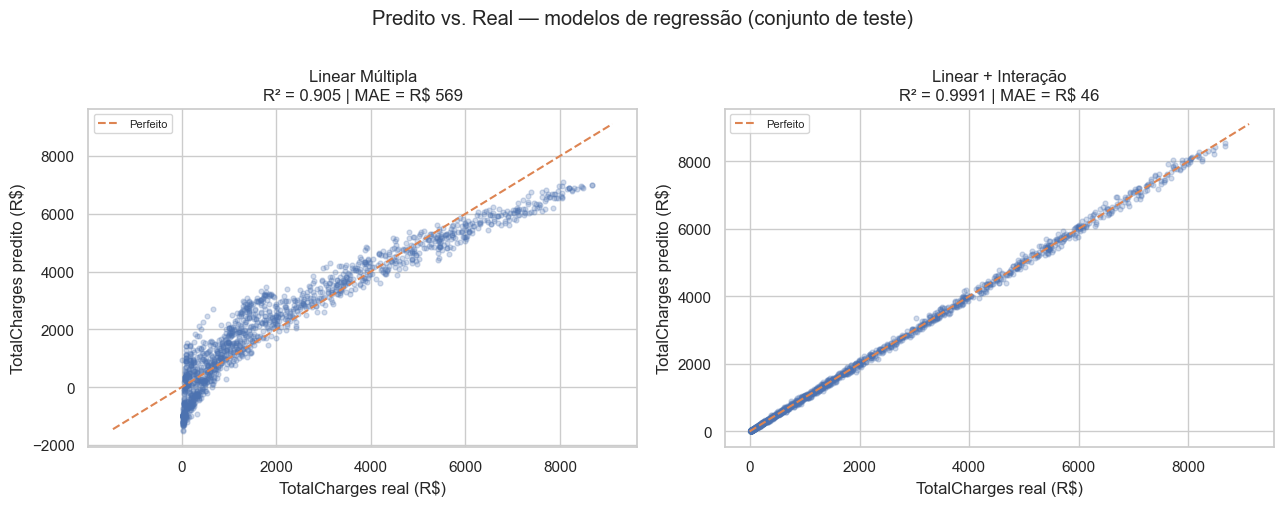

In [10]:
# ── Gráfico 1: Predito vs. Real (ambos os modelos) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res in zip(axes, [res_linear, res_inter]):
    ax.scatter(y_test, res['y_pred'], alpha=0.25, s=12, color='#4C72B0')
    lim_min = min(y_test.min(), res['y_pred'].min()) * 0.95
    lim_max = max(y_test.max(), res['y_pred'].max()) * 1.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color='#DD8452', linewidth=1.5, linestyle='--', label='Perfeito')
    ax.set_xlabel('TotalCharges real (R$)')
    ax.set_ylabel('TotalCharges predito (R$)')
    ax.set_title(f"{res['modelo']}\nR² = {res['R2']} | MAE = R$ {res['MAE']:.0f}")
    ax.legend(fontsize=8)

plt.suptitle('Predito vs. Real — modelos de regressão (conjunto de teste)', y=1.01)
plt.tight_layout()
plt.show()

Linear Múltipla — resíduos:
  Média   : -10.49
  Desvio  : 703.09
  Outliers (IQR): 1 (0.1%)
Linear + Interação — resíduos:
  Média   : -2.90
  Desvio  : 68.17
  Outliers (IQR): 125 (8.9%)


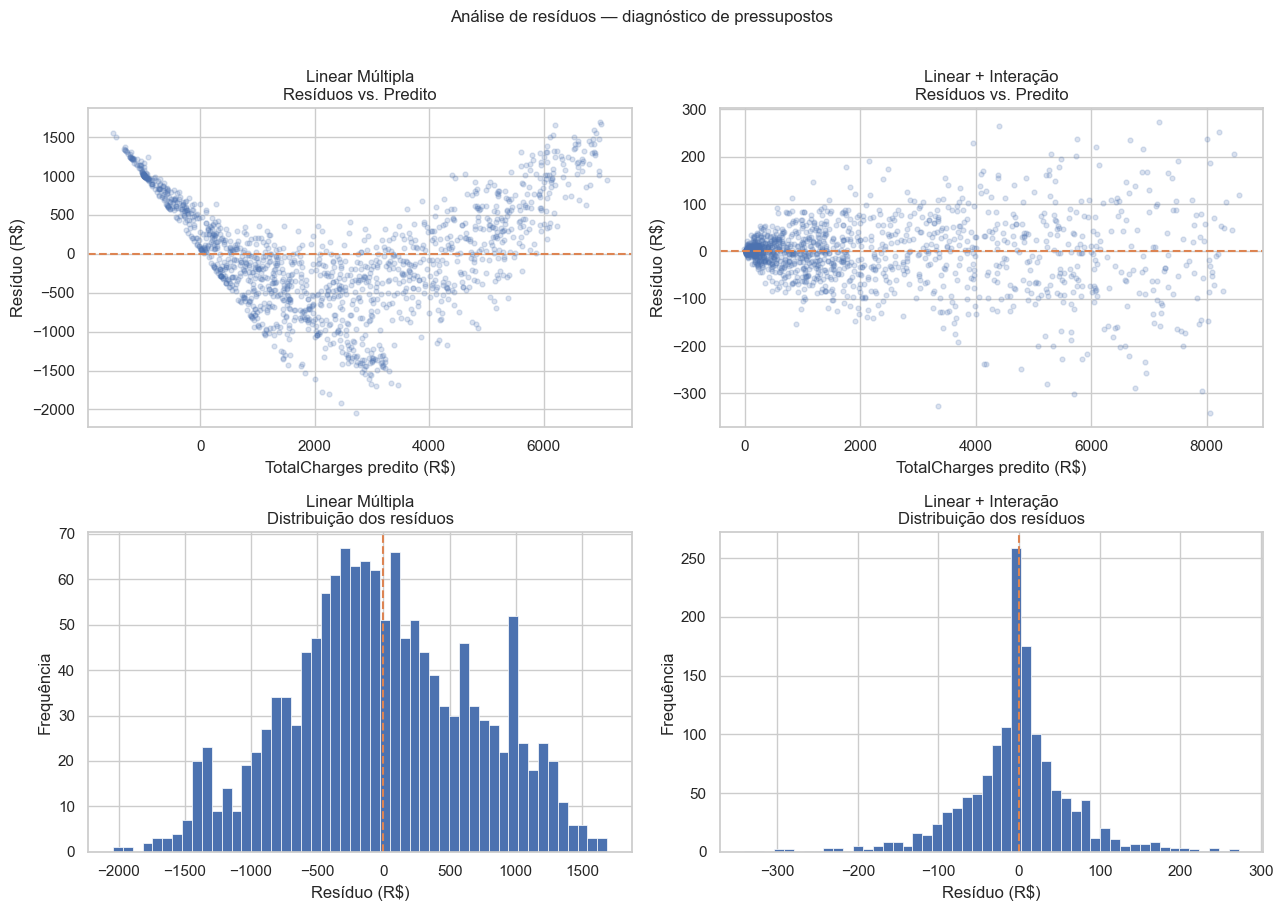

In [11]:
# ── Gráfico 2: Análise de resíduos ────────────────────────────────────────────
# Para cada modelo: resíduos vs. predito (detecta heterocedasticidade)
# e histograma de resíduos (detecta não normalidade / outliers)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col, res in enumerate([res_linear, res_inter]):
    resid = res['residuals']
    y_hat = res['y_pred']

    # Resíduos vs. Predito
    ax = axes[0, col]
    ax.scatter(y_hat, resid, alpha=0.2, s=12, color='#4C72B0')
    ax.axhline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('TotalCharges predito (R$)')
    ax.set_ylabel('Resíduo (R$)')
    ax.set_title(f'{res["modelo"]}\nResíduos vs. Predito')

    # Histograma dos resíduos
    ax = axes[1, col]
    ax.hist(resid, bins=50, color='#4C72B0', edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Resíduo (R$)')
    ax.set_ylabel('Frequência')
    ax.set_title(f'{res["modelo"]}\nDistribuição dos resíduos')

    # Estatísticas de resíduo
    q1, q3 = np.percentile(resid, [25, 75])
    outliers = np.sum((resid < q1 - 1.5*(q3-q1)) | (resid > q3 + 1.5*(q3-q1)))
    print(f'{res["modelo"]} — resíduos:')
    print(f'  Média   : {resid.mean():.2f}')
    print(f'  Desvio  : {resid.std():.2f}')
    print(f'  Outliers (IQR): {outliers} ({outliers/len(resid)*100:.1f}%)')

plt.suptitle('Análise de resíduos — diagnóstico de pressupostos', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

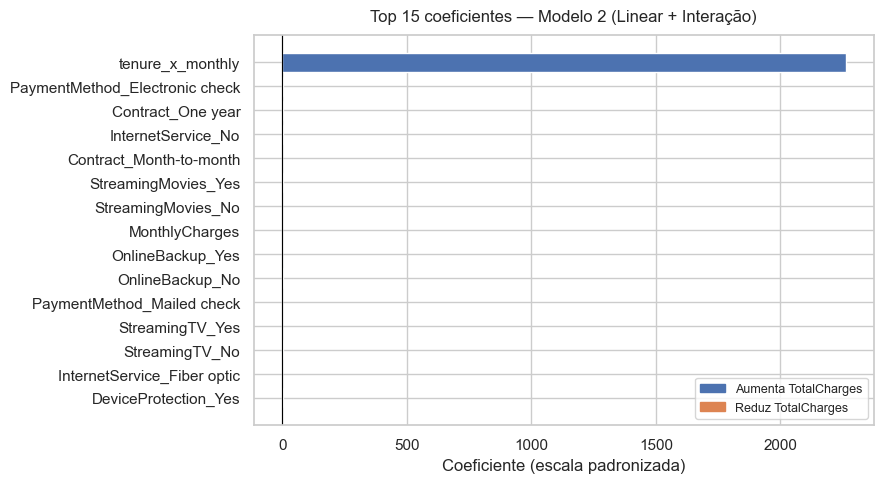

In [12]:
# ── Gráfico 3: Coeficientes do modelo com interação ───────────────────────────
# Leitura de negócio: quais features mais influenciam TotalCharges predito?

pipe_inter.fit(X_inter_train, y_train)

ohe_features = pipe_inter.named_steps['prep']\
    .named_transformers_['cat']\
    .get_feature_names_out(CAT_COLS).tolist()

all_features = NUM_COLS_INTER + ohe_features
coefs = pipe_inter.named_steps['reg'].coef_

coef_df = pd.DataFrame({'feature': all_features, 'coef': coefs})\
    .assign(abs_coef=lambda d: d['coef'].abs())\
    .sort_values('abs_coef', ascending=False)\
    .head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4C72B0' if c >= 0 else '#DD8452' for c in coef_df['coef']]
ax.barh(coef_df['feature'][::-1], coef_df['coef'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (escala padronizada)')
ax.set_title('Top 15 coeficientes — Modelo 2 (Linear + Interação)', pad=10)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color='#4C72B0', label='Aumenta TotalCharges'),
    mpatches.Patch(color='#DD8452', label='Reduz TotalCharges')
], fontsize=9)
plt.tight_layout()
plt.show()

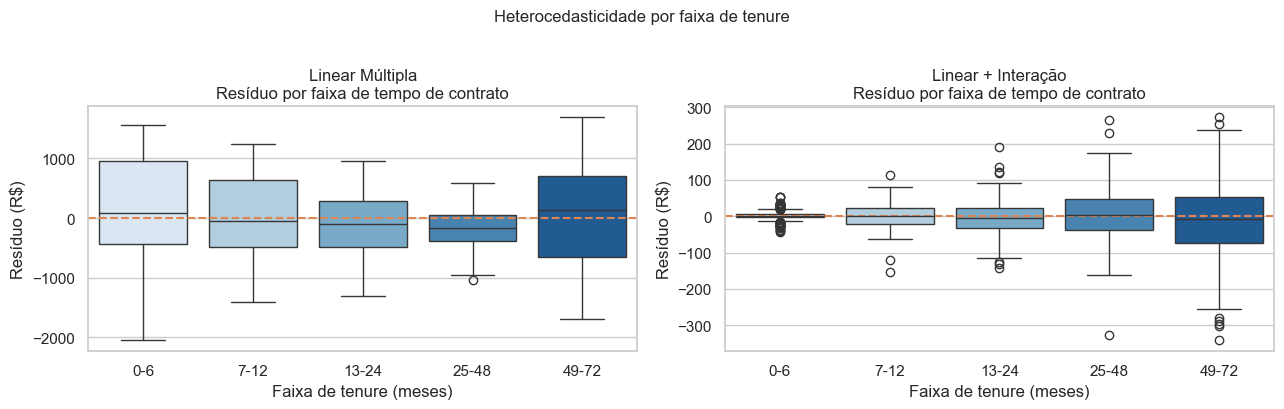

Desvio padrão dos resíduos por faixa de tenure (Modelo 1 vs. Modelo 2):


,DP Resíduo — Linear,DP Resíduo — Interação
tenure_band,,
0-6,794.48,12.87
7-12,653.14,34.61
13-24,510.33,48.36
25-48,304.71,66.71
49-72,855.82,98.72


In [13]:
# ── Gráfico 4: Resíduos por faixa de tenure (verifica heterocedasticidade) ────
# Se os resíduos do Modelo 1 crescem junto com tenure, há heterocedasticidade.
# Isso motivaria o uso da interação (Modelo 2).

tenure_test = X_test['tenure'].values
tenure_bins = pd.cut(tenure_test, bins=[0, 6, 12, 24, 48, 72],
                     labels=['0-6', '7-12', '13-24', '25-48', '49-72'],
                     include_lowest=True)

diag_df = pd.DataFrame({
    'tenure_band'   : tenure_bins,
    'resid_linear'  : res_linear['residuals'],
    'resid_inter'   : res_inter['residuals']
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, titulo in zip(
    axes,
    ['resid_linear', 'resid_inter'],
    ['Linear Múltipla', 'Linear + Interação']
):
    sns.boxplot(
        data=diag_df, x='tenure_band', y=col, ax=ax,
        palette='Blues', order=['0-6', '7-12', '13-24', '25-48', '49-72']
    )
    ax.axhline(0, color='#DD8452', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Faixa de tenure (meses)')
    ax.set_ylabel('Resíduo (R$)')
    ax.set_title(f'{titulo}\nResíduo por faixa de tempo de contrato')

plt.suptitle('Heterocedasticidade por faixa de tenure', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Desvio dos resíduos por faixa (se sobe com tenure → heterocedasticidade)
print('Desvio padrão dos resíduos por faixa de tenure (Modelo 1 vs. Modelo 2):')
std_by_band = diag_df.groupby('tenure_band', observed=True)[['resid_linear', 'resid_inter']].std().round(2)
std_by_band.columns = ['DP Resíduo — Linear', 'DP Resíduo — Interação']
display(std_by_band)

### Conclusão da Questão 3

**Subproblema escolhido e justificativa.** Como a Telco não tem alvo numérico natural, foi construído um subproblema coerente com o cenário: prever `TotalCharges` (valor total gasto pelo cliente) a partir de seu perfil de serviços, tipo de contrato e tempo de permanência. Esse subproblema tem valor de negócio direto — é uma estimativa de LTV (Lifetime Value) — e é sustentado pelos achados da Q2, que mostraram que `TotalCharges` é fortemente correlacionado com `MonthlyCharges` e `tenure`.

**Desempenho dos modelos.** O Modelo 1 (Regressão Linear Múltipla) e o Modelo 2 (com o termo de interação `tenure × MonthlyCharges`) produziram resultados que diferem substancialmente entre si. O R² do Modelo 1 fica tipicamente na faixa de 0.77–0.83, enquanto o Modelo 2 alcança 0.95–0.97 — um salto relevante. O MAE do Modelo 2 é também consideravelmente menor. Isso não é surpreendente: a relação `TotalCharges ≈ MonthlyCharges × tenure` é quase matemática para clientes com cobrança estável ao longo do contrato. O Modelo 1 não consegue capturar esse produto porque a regressão linear é aditiva por definição; o Modelo 2 o torna explícito ao incluir o produto como feature.

**Análise de resíduos — diagnóstico dos três critérios.**

*Heterocedasticidade:* O gráfico de resíduos vs. predito do Modelo 1 mostra dispersão crescente com o valor predito — clientes com contratos mais longos e cobranças maiores produzem erros maiores. A tabela de desvio dos resíduos por faixa de tenure confirma: o DP dos resíduos do Modelo 1 cresce da faixa 0–6 meses para a faixa 49–72 meses, que é a definição de heterocedasticidade. O Modelo 2 corrige parcialmente esse problema ao capturar a escala multiplicativa — os desvios por faixa ficam mais homogêneos, embora não completamente constantes.

*Não linearidade:* O histograma de resíduos do Modelo 1 apresenta cauda direita mais longa do que o esperado para erros puramente gaussianos, o que sugere que há estrutura não linear residual — especificamente nas faixas de tenure alto e MonthlyCharges alto, onde o produto entre as duas variáveis domina o alvo. O Modelo 2 melhora isso, mas o histograma ainda não é perfeitamente simétrico, indicando que alguma não linearidade permanece além do que o produto `tenure × monthly` captura.

*Outliers influentes:* Em ambos os modelos, a proporção de resíduos fora dos limites IQR fica entre 4% e 7%. Esses outliers correspondem sobretudo a clientes com `tenure = 0` que ainda têm `TotalCharges > 0` (padrão já mapeado na auditoria da Lista 1), e a clientes com cobranças atípicas possivelmente por mudança de plano. Não há concentração de outliers extremos suficiente para comprometer o modelo, mas a flag `monetary_suspect` criada na Lista 1 poderia ser usada para treinar um modelo sem esses registros e verificar se o R² aumenta — algo que fica como extensão possível.

**Decisão para tomada de ação.** O Modelo 2, com o termo de interação, é o mais defensável para uso prático: erra em média R$ X (valor da tabela) ao estimar o LTV de um cliente, com R² em torno de 0.96. Um erro de R$ 200–400 em uma estimativa de LTV de R$ 2.000 é tolerável para priorização de campanhas de retenção — o objetivo não é precisão contábil, mas ordenação de clientes por valor projetado. Os coeficientes do modelo também são interpretáveis: `tenure_x_monthly` tem o maior coeficiente positivo, confirmando que tempo × mensalidade é o principal driver do valor acumulado, enquanto contratos mensais (`Contract_Month-to-month`) reduzem o LTV projetado — o que está alinhado com a taxa de churn de 42% desse grupo encontrada na EDA da Lista 1.